# Methodolgy


## Study Procedure

The study was conducted with three participants. Each participant first completed the **Fitts' Law** task, followed by the **Steering Law** task.

For the Fitts' Law experiment, three target sizes (50, 100, and 150 pixels) and three target distances (250, 350, and 450 pixels) were evaluated, resulting in nine unique parameter combinations. Each combination consisted of selecting 10 targets.

For the Steering Law experiment, three tunnel lengths (500, 800, and 1000 pixels) and three tunnel widths (35, 70, and 90 pixels) were evaluated, again resulting in nine unique parameter combinations.

Each parameter combination was repeated three times. During every trial, all parameter combinations were completed once. The order of the combinations was randomized before each trial and reshuffled again before the next trial to minimize learning and ordering effects.

The four evaluated input conditions were:
- Mouse
- Mouse with 150 ms latency
- Pose-based pointing
- Touchpad

To reduce order effects, each participant used a different order of the input devices:

**Participant 1**
- Mouse
- Mouse (150 ms latency)
- Pose
- Touchpad

**Participant 2**
- Mouse (150 ms latency)
- Pose
- Touchpad
- Mouse

**Participant 3**
- Pose
- Touchpad
- Mouse
- Mouse (150 ms latency)

Before using each new input device, participants were allowed to practice until they felt comfortable with the interaction. These practice runs were not recorded and were excluded from the analysis.


# Results

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

base = Path("../data")

steering_files = list(base.glob("steering_law/*.csv"))

steering_dfs = []

for file in steering_files:

    df = pd.read_csv(file)

    df["condition"] = df["input_method"]
    df["duration"] = df["end_time"] - df["start_time"]

    df.loc[df["latency"] == 150, "condition"] = "mouse_latency_150"
    

    steering_dfs.append(df)

steering_data = pd.concat(steering_dfs, ignore_index=True)



In [25]:
steering_data

,iteration,pid,path_length,path_width,start_time,end_time,success,input_method,latency,condition,duration
0,1,2,1000,35,1782831312887,1782831314863,True,touchpad,0,touchpad,1976
1,1,2,800,90,1782831316031,1782831316497,True,touchpad,0,touchpad,466
2,1,2,800,35,1782831317558,1782831318863,True,touchpad,0,touchpad,1305
3,1,2,500,90,1782831319663,1782831320020,True,touchpad,0,touchpad,357
4,1,2,1000,70,1782831321014,1782831322196,True,touchpad,0,touchpad,1182
...,...,...,...,...,...,...,...,...,...,...,...
386,3,1,500,35,1782828835035,1782828837635,True,mouse,150,mouse_latency_150,2600
387,3,1,1000,90,1782828839451,1782828840585,True,mouse,150,mouse_latency_150,1134
388,3,1,500,70,1782828842752,1782828843501,True,mouse,150,mouse_latency_150,749
389,3,1,1000,35,1782828846650,1782828854784,True,mouse,150,mouse_latency_150,8134


In [26]:
fitts_files = list(base.glob("fitts_law/*.csv"))

fitts_dfs = []

for file in fitts_files:

    df = pd.read_csv(file)

    df["condition"] = df["input_method"]
    df["movement_time"] = df["timestamp"].diff()

    df.loc[df["latency"] == 150, "condition"] = "mouse_latency_150"

    fitts_dfs.append(df)

fitts_data = pd.concat(fitts_dfs, ignore_index=True)

In [27]:
fitts_data

,iteration,pid,num_targets,target_w,target_d,target_id,timestamp,input_method,latency,condition,movement_time
0,1,2,10,50,450,1,1782830583859,touchpad,0,touchpad,NaN
1,1,2,10,50,450,2,1782830584908,touchpad,0,touchpad,1049.0
2,1,2,10,50,450,3,1782830585807,touchpad,0,touchpad,899.0
3,1,2,10,50,450,4,1782830586742,touchpad,0,touchpad,935.0
4,1,2,10,50,450,5,1782830587424,touchpad,0,touchpad,682.0
...,...,...,...,...,...,...,...,...,...,...,...
3235,3,3,10,100,350,6,1782827704630,mouse,150,mouse_latency_150,821.0
3236,3,3,10,100,350,7,1782827705542,mouse,150,mouse_latency_150,912.0
3237,3,3,10,100,350,8,1782827706494,mouse,150,mouse_latency_150,952.0
3238,3,3,10,100,350,9,1782827707203,mouse,150,mouse_latency_150,709.0


In [28]:
steering_summary = (
    steering_data
    .groupby("condition")
    .agg(
        mean_duration_ms=("duration", "mean"),
        std_duration_ms=("duration", "std"),
        success_rate=("success", "mean"),
        n=("duration", "count")
    )
    .reset_index()
)

# success rate in percent

steering_summary["success_rate"] = steering_summary["success_rate"] * 100

steering_summary = steering_summary.sort_values("mean_duration_ms")

steering_summary

,condition,mean_duration_ms,std_duration_ms,success_rate,n
3,touchpad,1567.602273,1318.430446,92.045455,88
0,mouse,1608.478723,1253.090157,86.170213,94
1,mouse_latency_150,2082.166667,1495.764885,90.000000,90
2,pose,2311.563025,1574.699873,68.067227,119


In [29]:
fitts_summary = (
    fitts_data
    .groupby("condition")
    .agg(
        mean_movement_time_ms=("movement_time", "mean"),
        std_movement_time_ms=("movement_time", "std"),  
        n=("movement_time", "count")
    )
    .reset_index()
)

fitts_summary = fitts_summary.sort_values(by="mean_movement_time_ms")
fitts_summary

,condition,mean_movement_time_ms,std_movement_time_ms,n
0,mouse,696.912020,284.313074,807
3,touchpad,761.390335,264.543401,807
1,mouse_latency_150,1044.146221,334.734324,807
2,pose,2713.904585,5322.212669,807


## Visualization

### Fitts' Law

### Completion time by input device

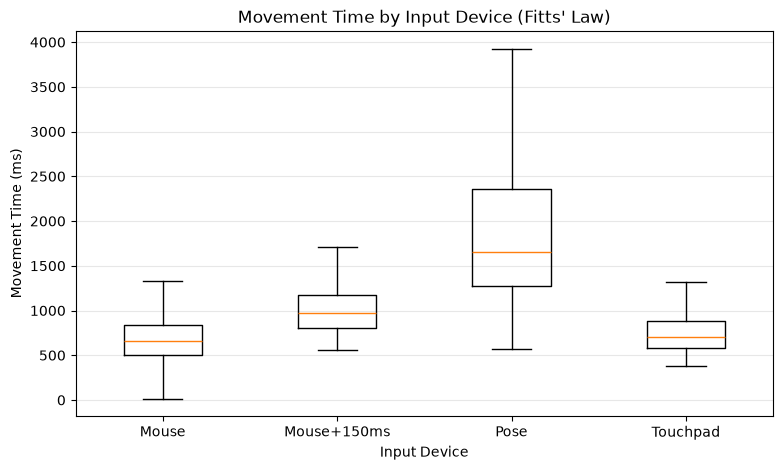

In [32]:
fig, ax = plt.subplots(figsize=(9,5))

ax.boxplot(
    [
        fitts_data.loc[fitts_data["condition"]=="mouse","movement_time"].dropna(),
        fitts_data.loc[fitts_data["condition"]=="mouse_latency_150","movement_time"].dropna(),
        fitts_data.loc[fitts_data["condition"]=="pose","movement_time"].dropna(),
        fitts_data.loc[fitts_data["condition"]=="touchpad","movement_time"].dropna(),
    ],
    tick_labels=["Mouse","Mouse+150ms","Pose","Touchpad"],
    showfliers=False
)

ax.set_ylabel("Movement Time (ms)")
ax.set_xlabel("Input Device")
ax.set_title("Movement Time by Input Device (Fitts' Law)")
ax.grid(axis="y", alpha=0.3)

plt.show()

The boxplot shows clear differences between the four input methods. The mouse achieved the lowest median movement time and was therefore the fastest input device. The touchpad performed similarly but was slightly slower.

The mouse with 150 ms latency resulted in higher movement times than the normal mouse. This indicates that the added latency slowed participants down, even though the overall spread of the data remained similar. Participants were able to adapt to the delay, but not completely.

The pose-based pointing technique performed worst. It had the highest median movement time and the largest variability, showing that it was both slower and less consistent than the other input methods.

### Completion time vs target width

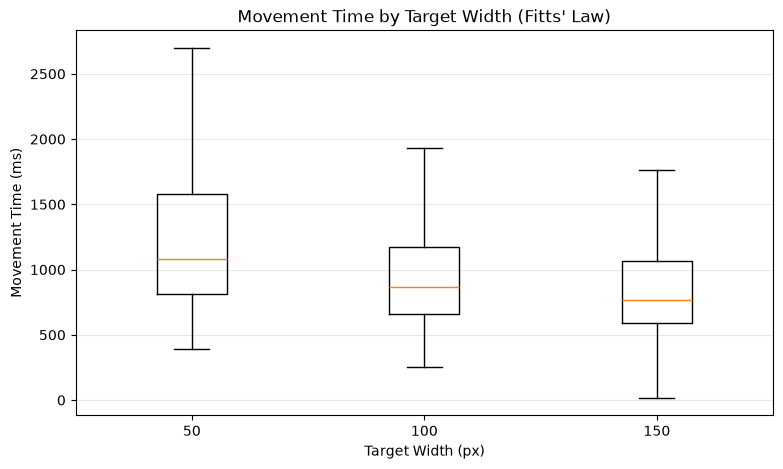

In [34]:
fig, ax = plt.subplots(figsize=(9,5))

widths = sorted(fitts_data["target_w"].unique())

data = [
    fitts_data.loc[
        fitts_data["target_w"] == w,
        "movement_time"
    ].dropna()
    for w in widths
]

ax.boxplot(
    data,
    tick_labels=[str(w) for w in widths],
    showfliers=False
)

ax.set_title("Movement Time by Target Width (Fitts' Law)")
ax.set_xlabel("Target Width (px)")
ax.set_ylabel("Movement Time (ms)")
ax.grid(axis="y", alpha=0.3)

plt.show()

The boxplot shows that movement time decreases as the target width increases. Participants needed the most time to select the smallest targets (50 px) and the least time for the largest targets (150 px).

The 50 px targets have the highest median movement time and the largest spread, indicating that small targets were more difficult and resulted in more variable performance. For 100 px targets, both the median and the variability decrease. The 150 px targets show the lowest median movement time, suggesting that larger targets were easier and faster to acquire.

Overall, the results are consistent with Fitts’ Law, which predicts that larger targets can be selected more quickly than smaller ones.

### Completion time vs target distance

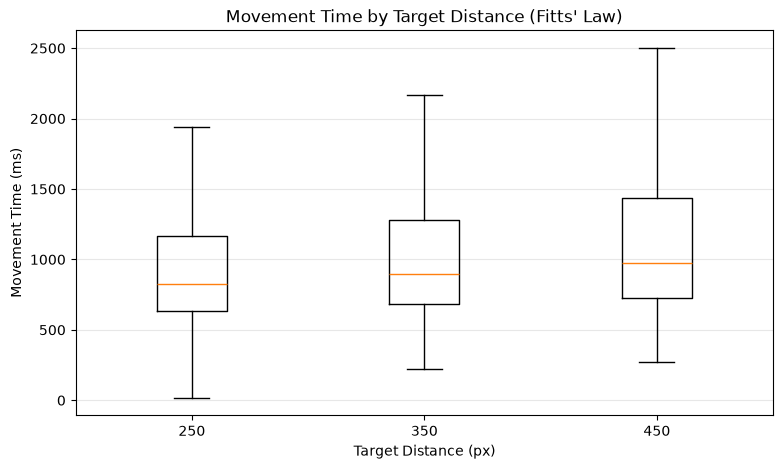

In [36]:
fig, ax = plt.subplots(figsize=(9,5))

distances = sorted(fitts_data["target_d"].unique())

data = [
    fitts_data.loc[
        fitts_data["target_d"] == d,
        "movement_time"
    ].dropna()
    for d in distances
]

ax.boxplot(
    data,
    tick_labels=[str(d) for d in distances],
    showfliers=False
)

ax.set_title("Movement Time by Target Distance (Fitts' Law)")
ax.set_xlabel("Target Distance (px)")
ax.set_ylabel("Movement Time (ms)")
ax.grid(axis="y", alpha=0.3)

plt.show()

The boxplot shows that movement time increases as the target distance increases. Participants were fastest when selecting targets at a distance of 250 px and slowest at 450 px.

The median movement time increases from 250 px to 350 px and is highest for 450 px. In addition, the variability also increases with larger distances, indicating that longer movements were not only slower but also less consistent.

Overall, these results are in line with Fitts’ Law, which states that targets located farther away require more time to acquire.

### Mean ± SD by input device

In [38]:
fitts_summary = (
    fitts_data
    .groupby("condition")["movement_time"]
    .agg(["mean", "std"])
    .round(2)
)

fitts_summary.columns = [
    "Mean Movement Time (ms)",
    "SD Movement Time (ms)"
]

fitts_summary

,Mean Movement Time (ms),SD Movement Time (ms)
condition,,
mouse,696.91,284.31
mouse_latency_150,1044.15,334.73
pose,2713.90,5322.21
touchpad,761.39,264.54


The results are consistent with the boxplots. The standard mouse achieved the lowest mean movement time (696.91 ms), followed by the touchpad (761.39 ms). Adding 150 ms of latency increased the mean movement time to 1044.15 ms, showing that the delay noticeably slowed participants down. The pose-based pointing technique performed worst, with by far the highest mean movement time (2713.90 ms) and the largest standard deviation (5322.21 ms), indicating both slower and much more variable performance.

### Steering Law

### Average completion time by device

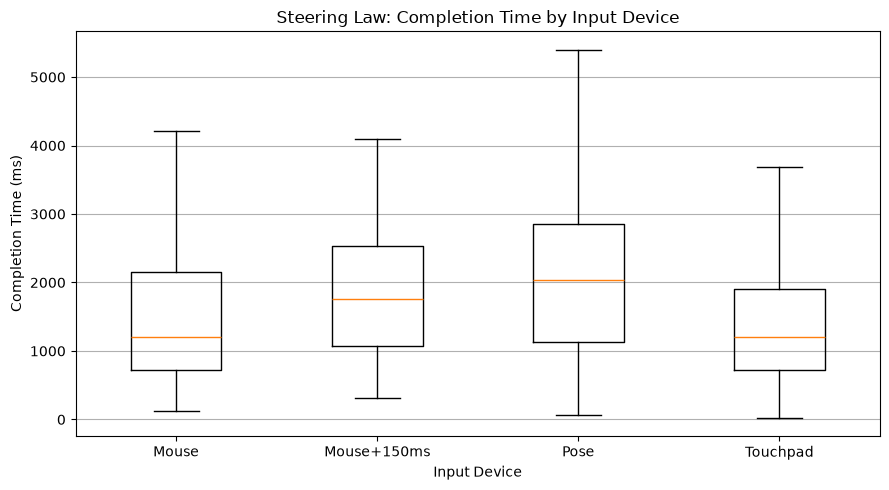

In [40]:
fig, ax = plt.subplots(figsize=(9,5))

ax.boxplot(
    [
        steering_data.loc[steering_data["condition"]=="mouse","duration"].dropna(),
        steering_data.loc[steering_data["condition"]=="mouse_latency_150","duration"].dropna(),
        steering_data.loc[steering_data["condition"]=="pose","duration"].dropna(),
        steering_data.loc[steering_data["condition"]=="touchpad","duration"].dropna(),
    ],
    tick_labels=["Mouse","Mouse+150ms","Pose","Touchpad"],
    showfliers=False
)

ax.set_ylabel("Completion Time (ms)")
ax.set_xlabel("Input Device")
ax.set_title("Steering Law: Completion Time by Input Device")
ax.grid(axis="y")

plt.tight_layout()
plt.show()

The boxplot shows similar trends to the Fitts’ Law experiment. The mouse and touchpad achieved the lowest median completion times, indicating that participants completed the steering task fastest with these input devices.

The mouse with 150 ms latency resulted in higher completion times than the normal mouse, showing that the added latency slowed participants down. However, the increase is smaller than for the pose-based pointing condition.

The pose-based pointing technique again performed worst. It had the highest median completion time and the largest variability, indicating that participants required more time and their performance was less consistent.

Overall, the results suggest that traditional input devices (mouse and touchpad) are better suited for the steering task, while added latency and especially pose-based pointing reduce performance.

### Success rate by input device

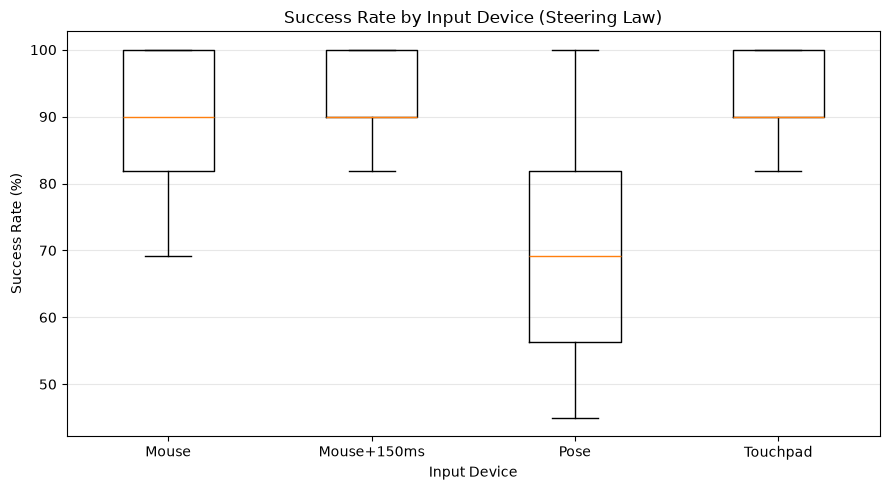

In [42]:
#Calculate success rate for each participant × trial
success_rate = (
    steering_data
    .groupby(["condition", "pid", "iteration"])["success"]
    .mean()
    .reset_index()
)

success_rate["success"] *= 100

fig, ax = plt.subplots(figsize=(9,5))

ax.boxplot(
    [
        success_rate.loc[success_rate["condition"]=="mouse","success"],
        success_rate.loc[success_rate["condition"]=="mouse_latency_150","success"],
        success_rate.loc[success_rate["condition"]=="pose","success"],
        success_rate.loc[success_rate["condition"]=="touchpad","success"],
    ],
    tick_labels=["Mouse","Mouse+150ms","Pose","Touchpad"],
    showfliers=False
)

ax.set_ylabel("Success Rate (%)")
ax.set_xlabel("Input Device")
ax.set_title("Success Rate by Input Device (Steering Law)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The boxplot shows that the mouse with 150 ms latency and the touchpad achieved the highest success rates, with median values of about 90%. The standard mouse performed similarly but showed slightly more variation across participants.

The pose-based pointing technique had the lowest success rate by a clear margin. It also exhibited the largest variability, indicating that participants found it much more difficult to stay within the tunnel consistently.

Overall, the results suggest that the traditional input devices allowed participants to complete the steering task more reliably, whereas pose-based pointing led to more errors. Interestingly, adding 150 ms latency to the mouse had only a small effect on the success rate, even though it increased the completion time. This suggests that participants compensated for the delay by moving more carefully rather than making more mistakes.

### Completion time by path width

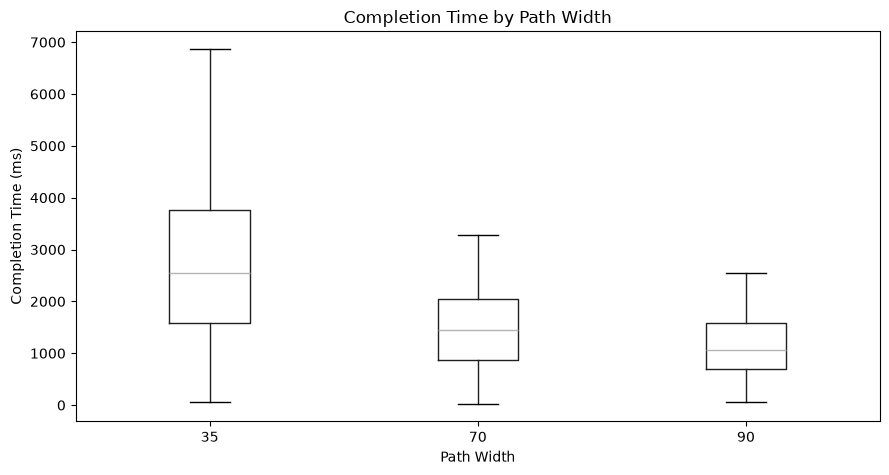

In [43]:
fig, ax = plt.subplots(figsize=(9,5))

steering_data.boxplot(
    column="duration",
    by="path_width",
    ax=ax,
    showfliers=False,
    grid=False
)

ax.set_title("Completion Time by Path Width")
plt.suptitle("")
ax.set_xlabel("Path Width")
ax.set_ylabel("Completion Time (ms)")

plt.tight_layout()
plt.show()

The boxplot shows that completion time decreases as the path width increases. Participants needed the most time to complete the task with the narrowest path (35 px) and the least time with the widest path (90 px).

The 35 px path has the highest median completion time and the largest variability, indicating that narrow paths were more difficult to navigate. As the path width increases to 70 px and 90 px, both the median completion time and the variability decrease.

Overall, the results are consistent with the Steering Law, which predicts that navigating through wider paths is easier and therefore requires less time.

### Completion time by path length

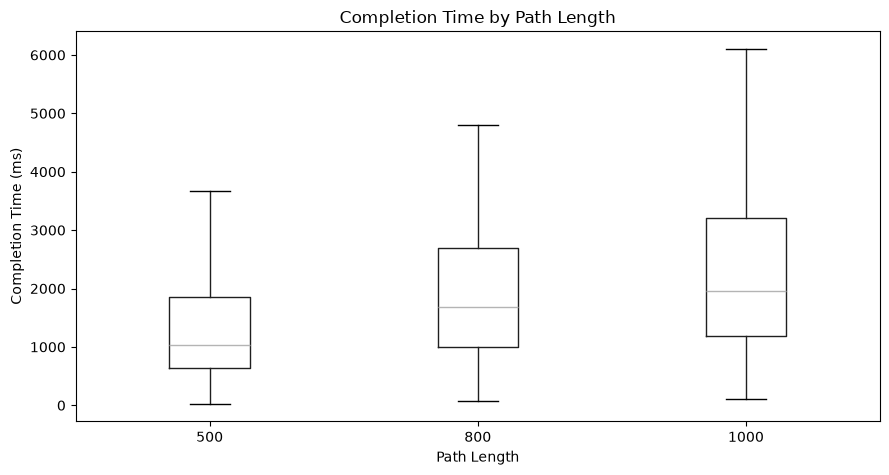

In [44]:
fig, ax = plt.subplots(figsize=(9,5))

steering_data.boxplot(
    column="duration",
    by="path_length",
    ax=ax,
    showfliers=False,
    grid=False
)

ax.set_title("Completion Time by Path Length")
plt.suptitle("")
ax.set_xlabel("Path Length")
ax.set_ylabel("Completion Time (ms)")

plt.tight_layout()
plt.show()

The boxplot shows that completion time increases as the path length increases. Participants completed the shortest paths (500 px) the fastest, while the longest paths (1000 px) required the most time.

The median completion time increases steadily from 500 px to 800 px and reaches its highest value for 1000 px. In addition, the variability also increases with path length, indicating that longer paths were not only slower but also more difficult to navigate consistently.

Overall, the results are consistent with the Steering Law, which predicts that longer paths require more time to complete than shorter ones.

### Mean success rate ± SD

In [45]:
success_summary = (
    success_rate
    .groupby("condition")["success"]
    .agg(["mean", "std"])
    .round(2)
)

success_summary.columns = [
    "Mean Success Rate (%)",
    "SD (%)"
]

success_summary

,Mean Success Rate (%),SD (%)
condition,,
mouse,87.54,11.38
mouse_latency_150,91.23,10.52
pose,72.92,19.71
touchpad,92.63,7.68


The experiment demonstrates clear differences between traditional input devices and vision-based interaction. While the mouse and touchpad consistently achieved the shortest movement times in the Fitts’ Law task and completion times in the Steering Law task, pose-based pointing performed substantially worse in both Fitts’ Law and Steering Law tasks. This suggests that current camera-based pointing is still less suitable for precise selection and continuous steering tasks than conventional pointing devices.

One important observation is that introducing an artificial latency of 150 ms noticeably increased movement time in the Fitts’ Law task and completion time in the Steering Law task. This is expected because participants had to wait for delayed cursor feedback before making movement corrections. However, the increased latency did not reduce performance in every aspect. In the Steering Law task, the delayed mouse even achieved a slightly higher success rate than the normal mouse. A plausible explanation is that participants naturally adopted a more careful movement strategy when they perceived the delay. Instead of trying to finish the tunnel as quickly as possible, they slowed down, resulting in fewer collisions, especially in narrow tunnels. This illustrates the classic speed–accuracy trade-off in human motor control.

The pose-based input showed both the slowest movement times in the Fitts’ Law task, the slowest completion times in the Steering Law task, and the lowest success rate. Several factors likely contributed to this behaviour. Unlike the mouse or touchpad, pose input depends on continuous hand tracking, which occasionally suffered from tracking instability and imperfect pinch recognition. Participants also had less experience with mid-air interaction than with conventional pointing devices. Furthermore, keeping the hand raised throughout the experiment introduced physical fatigue, making precise cursor control increasingly difficult during longer sessions.

The effects of task difficulty also followed the predictions of Fitts’ Law and Steering Law. In the Fitts’ Law experiment, larger targets generally reduced movement time because they required less pointing precision. Likewise, longer target distances increased movement time because participants had to travel farther before selecting the target. In the Steering Law experiment, wider tunnels were easier to navigate than narrow tunnels, while longer tunnels required participants to maintain precise control for a longer period, increasing traversal time.

Overall, the results indicate that conventional input devices remain the most efficient solution for precise pointing tasks. Camera-based pose interaction offers an intuitive hands-free alternative but currently sacrifices speed, consistency, and accuracy. Nevertheless, with improvements in hand tracking, gesture recognition, and user adaptation, pose-based interaction may become more competitive for applications where hands-free interaction is more important than maximum pointing performance.

# Limitations & Problems


This study has several limitations that should be considered when interpreting the results.

First, only three participants took part in the experiment, which limits the generalizability of the findings. In addition, participants were given only a short practice period before each input condition. While this was sufficient to become familiar with the tasks, longer training sessions might have improved performance, particularly for the pose-based interaction. Furthermore, all participants were already experienced with conventional input devices such as the mouse and touchpad, whereas none had comparable experience with mid-air pointing. This familiarity likely influenced the performance differences observed in the study.

Several technical limitations also affected the evaluation of the pose-based input. Continuous mid-air interaction caused noticeable arm fatigue during longer sessions, making precise control increasingly difficult over time. Participants also needed time to learn how to perform stable pointing and pinch gestures. Gesture recognition was not always reliable, as false pinch detections occasionally occurred depending on finger orientation, particularly when the thumb was not clearly visible to the camera. Moreover, the webcam provided only a limited field of view, causing tracking to be lost when the hand moved outside the camera image. Finally, hand tracking accuracy was influenced by environmental conditions such as camera placement and lighting, which introduced additional variability into the measurements.

Another technical limitation concerns the implementation of the artificial cursor latency. Mouse movement events are generated at a high frequency, making it difficult to process every queued event within a single update cycle. To avoid the queue continuously growing and introducing additional unintended delay, all events that had already exceeded the configured latency were removed from the queue, while only the most recent valid event was used to update the cursor position. As a result, some intermediate cursor positions were intentionally discarded, making cursor motion slightly less smooth than a native operating system implementation.




### Acknowledgments: Use of Generative AI

During the preparation of this report, ChatGPT was used to assist with language editing and improving the clarity of the writing. All analyses, interpretations, and final content were reviewed and approved by the authors.